# Bank Marketing 新手友好调优版

这个 notebook 的目标是：用银行电话营销历史数据，预测客户是否会认购定期存款。

你可以把它当成一个完整的数据分析学习路径：

1. 认识数据和业务问题
2. 做基础探索分析
3. 处理适合建模的特征
4. 训练一个容易解释的基线模型
5. 调优一个表现更好的 LightGBM 模型
6. 选择分类阈值并解释结果

> 重要提醒：`duration` 是通话结束后才知道的信息。如果我们要在打电话之前预测客户是否值得联系，就不能使用它。


## 1. 导入工具包

这一格只做准备工作。`pandas` 用来处理表格，`sklearn` 和 `lightgbm` 用来建模，`matplotlib/seaborn` 用来画图。


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import ParameterGrid, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import lightgbm as lgb

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

PROJECT_DIR = Path.cwd()
DATA_PATH = PROJECT_DIR / "bank-additional-full.csv"
FIGURE_DIR = PROJECT_DIR / "figures_beginner"
FIGURE_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")
plt.rcParams["axes.unicode_minus"] = False


C:\Python312\Lib\site-packages\dask\dataframe\__init__.py:49: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


## 2. 读取数据

这个 CSV 文件使用分号 `;` 分隔，所以读取时要写 `sep=';'`。


In [2]:
df = pd.read_csv(DATA_PATH, sep=";")

print(f"数据规模: {df.shape[0]:,} 行, {df.shape[1]} 列")
display(df.head())


数据规模: 41,188 行, 21 列


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 3. 先理解目标变量

我们要预测的是 `y`：

- `yes`：客户认购了定期存款
- `no`：客户没有认购

这个数据集是典型的不平衡分类问题，因为 `yes` 比例比较低。


,count,rate_%
y,,
no,36548,88.73
yes,4640,11.27


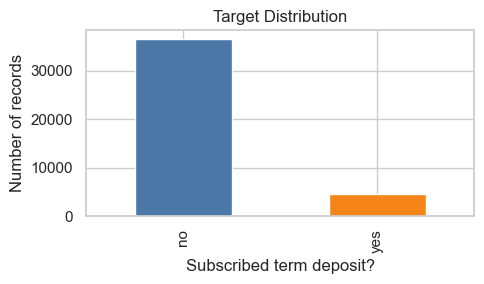

In [3]:
target_counts = df["y"].value_counts()
target_rates = df["y"].value_counts(normalize=True).mul(100).round(2)

target_summary = pd.DataFrame({
    "count": target_counts,
    "rate_%": target_rates,
})
display(target_summary)

ax = target_counts.loc[["no", "yes"]].plot(kind="bar", figsize=(5, 3), color=["#4C78A8", "#F58518"])
ax.set_title("Target Distribution")
ax.set_xlabel("Subscribed term deposit?")
ax.set_ylabel("Number of records")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "target_distribution.png", dpi=150)
plt.show()


## 4. 检查缺失信息

表面上没有空值，但很多分类字段用 `unknown` 表示未知。建模时我们先保留 `unknown`，让模型自己学习它是否有信息量。


In [4]:
unknown_counts = []
for col in df.columns:
    count = int((df[col].astype(str) == "unknown").sum())
    if count > 0:
        unknown_counts.append({
            "column": col,
            "unknown_count": count,
            "unknown_rate_%": round(count / len(df) * 100, 2),
        })

display(pd.DataFrame(unknown_counts))


,column,unknown_count,unknown_rate_%
0,job,330,0.80
1,marital,80,0.19
2,education,1731,4.20
3,default,8597,20.87
4,housing,990,2.40
5,loan,990,2.40


## 5. 特征工程：把原始数据变成模型能读的形式

这里有三个关键处理：

1. 删除 `duration`，避免事后信息泄漏。
2. 把 `pdays=999` 拆成两个字段：是否曾经联系过、距离上次联系多少天。
3. 把分类变量转成 0/1 哑变量。

我们保留宏观经济变量，因为它们在营销时点通常已经可知，而且实验显示它们能提升效果。


In [5]:
def build_model_data(data, include_macro=True, include_duration=False):
    y = (data["y"] == "yes").astype(int)

    drop_cols = ["y"]
    if not include_duration:
        drop_cols.append("duration")
    if not include_macro:
        drop_cols += [
            "emp.var.rate",
            "cons.price.idx",
            "cons.conf.idx",
            "euribor3m",
            "nr.employed",
        ]

    X = data.drop(columns=drop_cols).copy()

    X["has_prev_contact"] = (X["pdays"] != 999).astype(int)
    X["pdays_clean"] = X["pdays"].where(X["pdays"] != 999, 0)
    X = X.drop(columns=["pdays"])

    X = pd.get_dummies(X, drop_first=False, dtype=float)
    return X, y


X, y = build_model_data(df, include_macro=True, include_duration=False)

print(f"建模特征矩阵: {X.shape[0]:,} 行, {X.shape[1]} 个特征")
display(X.head())


建模特征矩阵: 41,188 行, 63 个特征


,age,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,has_prev_contact,pdays_clean,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_divorced,marital_married,marital_single,marital_unknown,education_basic.4y,education_basic.6y,education_basic.9y,education_high.school,education_illiterate,education_professional.course,education_university.degree,education_unknown,default_no,default_unknown,default_yes,housing_no,housing_unknown,housing_yes,loan_no,loan_unknown,loan_yes,contact_cellular,contact_telephone,month_apr,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
0,56,1,0,1.1,93.994,-36.4,4.857,5191.0,0,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,57,1,0,1.1,93.994,-36.4,4.857,5191.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,37,1,0,1.1,93.994,-36.4,4.857,5191.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,40,1,0,1.1,93.994,-36.4,4.857,5191.0,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,56,1,0,1.1,93.994,-36.4,4.857,5191.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


## 6. 划分训练集、验证集、测试集

新手最容易犯的错是：在测试集上反复调参数。这里我们分成三份：

- 训练集：训练模型
- 验证集：选择参数和分类阈值
- 测试集：最后只评估一次


In [6]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

print(f"训练集: {X_train.shape}")
print(f"验证集: {X_val.shape}")
print(f"测试集: {X_test.shape}")


训练集: (24712, 63)
验证集: (8238, 63)
测试集: (8238, 63)


## 7. 准备评估函数

因为 `yes` 很少，不能只看 accuracy。我们重点看：

- ROC-AUC：整体排序能力
- PR-AUC：少数类 `yes` 的识别质量，更适合不平衡数据
- precision/recall/F1：选定阈值后的实际分类效果


In [7]:
def find_best_f1_threshold(y_true, predicted_prob):
    precision, recall, thresholds = precision_recall_curve(y_true, predicted_prob)
    f1_scores = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
    best_idx = int(np.argmax(f1_scores))
    return {
        "threshold": float(thresholds[best_idx]),
        "precision": float(precision[best_idx]),
        "recall": float(recall[best_idx]),
        "f1": float(f1_scores[best_idx]),
    }


def evaluate_model(name, model, X_val, y_val, X_test, y_test):
    val_prob = model.predict_proba(X_val)[:, 1]
    threshold_info = find_best_f1_threshold(y_val, val_prob)
    threshold = threshold_info["threshold"]

    test_prob = model.predict_proba(X_test)[:, 1]
    test_pred = (test_prob >= threshold).astype(int)

    return {
        "model": name,
        "threshold_from_val": threshold,
        "val_pr_auc": average_precision_score(y_val, val_prob),
        "val_roc_auc": roc_auc_score(y_val, val_prob),
        "test_pr_auc": average_precision_score(y_test, test_prob),
        "test_roc_auc": roc_auc_score(y_test, test_prob),
        "test_precision_yes": precision_score(y_test, test_pred, zero_division=0),
        "test_recall_yes": recall_score(y_test, test_pred, zero_division=0),
        "test_f1_yes": f1_score(y_test, test_pred, zero_division=0),
        "test_pred_yes_rate": test_pred.mean(),
        "confusion_matrix": confusion_matrix(y_test, test_pred),
        "test_prob": test_prob,
        "test_pred": test_pred,
    }


## 8. 基线模型：Logistic 回归

Logistic 回归是很好的入门基线：速度快、稳定、容易解释。我们用 `class_weight='balanced'` 告诉模型更重视少数类。


In [8]:
logistic_model = make_pipeline(
    StandardScaler(with_mean=False),
    LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        solver="liblinear",
        random_state=RANDOM_STATE,
    ),
)

logistic_model.fit(X_train, y_train)
logistic_result = evaluate_model("Logistic Regression", logistic_model, X_val, y_val, X_test, y_test)

pd.DataFrame([{
    k: v for k, v in logistic_result.items()
    if k not in ["confusion_matrix", "test_prob", "test_pred"]
}]).round(4)


,model,threshold_from_val,val_pr_auc,val_roc_auc,test_pr_auc,test_roc_auc,test_precision_yes,test_recall_yes,test_f1_yes,test_pred_yes_rate
0,Logistic Regression,0.6539,0.4368,0.7973,0.4582,0.8011,0.4413,0.5797,0.5012,0.148


## 9. 主力模型：LightGBM 默认版本

LightGBM 是梯度提升树模型，常用于表格数据。先训练一个默认版本，作为调优前的对照组。


In [9]:
lgb_default = lgb.LGBMClassifier(
    objective="binary",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
)

lgb_default.fit(X_train, y_train)
lgb_default_result = evaluate_model("LightGBM Default", lgb_default, X_val, y_val, X_test, y_test)

pd.DataFrame([{
    k: v for k, v in lgb_default_result.items()
    if k not in ["confusion_matrix", "test_prob", "test_pred"]
}]).round(4)


,model,threshold_from_val,val_pr_auc,val_roc_auc,test_pr_auc,test_roc_auc,test_precision_yes,test_recall_yes,test_f1_yes,test_pred_yes_rate
0,LightGBM Default,0.1997,0.4626,0.8012,0.4798,0.8083,0.4574,0.5905,0.5155,0.1454


## 10. 小范围参数调优

这里不追求把所有参数都搜一遍，而是搜索几组最常影响效果和过拟合的参数。

调优标准用验证集 PR-AUC，因为它更关注少数类 `yes` 的识别质量。


In [10]:
param_grid = list(ParameterGrid({
    "n_estimators": [300, 600, 900],
    "learning_rate": [0.02, 0.03, 0.05],
    "num_leaves": [15, 31],
    "max_depth": [4, 6, -1],
    "min_child_samples": [40, 80, 120],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8],
    "reg_alpha": [0, 0.1],
    "reg_lambda": [0, 1],
}))

rng = np.random.default_rng(RANDOM_STATE)
sampled_indices = rng.choice(len(param_grid), size=36, replace=False)
search_grid = [param_grid[i] for i in sampled_indices]

search_grid += [
    {
        "n_estimators": 600,
        "learning_rate": 0.03,
        "num_leaves": 31,
        "max_depth": 6,
        "min_child_samples": 80,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "reg_alpha": 0.1,
        "reg_lambda": 1,
    },
    {
        "n_estimators": 900,
        "learning_rate": 0.02,
        "num_leaves": 31,
        "max_depth": 4,
        "min_child_samples": 80,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "reg_alpha": 0.1,
        "reg_lambda": 1,
    },
]

best_score = -np.inf
best_params = None
best_lgb_model = None
tuning_rows = []

for i, params in enumerate(search_grid, start=1):
    model = lgb.LGBMClassifier(
        objective="binary",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
        **params,
    )
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="auc",
        callbacks=[lgb.early_stopping(80, verbose=False)],
    )

    val_prob = model.predict_proba(X_val)[:, 1]
    val_pr_auc = average_precision_score(y_val, val_prob)
    val_roc_auc = roc_auc_score(y_val, val_prob)
    tuning_rows.append({"candidate": i, "val_pr_auc": val_pr_auc, "val_roc_auc": val_roc_auc, **params})

    if val_pr_auc > best_score:
        best_score = val_pr_auc
        best_params = params
        best_lgb_model = model

tuning_results = pd.DataFrame(tuning_rows).sort_values("val_pr_auc", ascending=False)
display(tuning_results.head(10).round(4))

print("最佳参数:")
print(best_params)


,candidate,val_pr_auc,val_roc_auc,colsample_bytree,learning_rate,max_depth,min_child_samples,n_estimators,num_leaves,reg_alpha,reg_lambda,subsample
11,12,0.4757,0.8112,0.8,0.03,-1,120,300,31,0.1,0,0.8
13,14,0.4753,0.8107,0.8,0.05,6,120,900,31,0.1,0,1.0
0,1,0.4739,0.8085,0.8,0.03,6,40,300,15,0.0,0,0.8
34,35,0.4737,0.8094,0.8,0.03,6,120,600,31,0.1,1,1.0
28,29,0.4734,0.8106,0.8,0.03,6,80,900,31,0.1,0,1.0
14,15,0.4733,0.8119,0.8,0.03,-1,120,300,31,0.0,1,0.8
19,20,0.4732,0.8085,0.8,0.05,4,40,600,15,0.1,0,0.8
25,26,0.4731,0.8094,0.8,0.05,-1,80,900,31,0.0,0,0.8
35,36,0.4730,0.8077,0.8,0.03,6,40,300,15,0.1,0,1.0
8,9,0.4728,0.8067,0.8,0.05,4,120,300,31,0.0,0,1.0


最佳参数:
{'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': -1, 'min_child_samples': 120, 'n_estimators': 300, 'num_leaves': 31, 'reg_alpha': 0.1, 'reg_lambda': 0, 'subsample': 0.8}


## 11. 最终模型评估

用验证集选择最佳阈值，然后在测试集上评估。测试集结果才是我们对泛化效果的估计。


In [11]:
tuned_result = evaluate_model("LightGBM Tuned", best_lgb_model, X_val, y_val, X_test, y_test)

comparison = pd.DataFrame([
    {k: v for k, v in logistic_result.items() if k not in ["confusion_matrix", "test_prob", "test_pred"]},
    {k: v for k, v in lgb_default_result.items() if k not in ["confusion_matrix", "test_prob", "test_pred"]},
    {k: v for k, v in tuned_result.items() if k not in ["confusion_matrix", "test_prob", "test_pred"]},
])

metric_cols = [
    "model",
    "threshold_from_val",
    "val_pr_auc",
    "test_pr_auc",
    "test_roc_auc",
    "test_precision_yes",
    "test_recall_yes",
    "test_f1_yes",
    "test_pred_yes_rate",
]
display(comparison[metric_cols].round(4))

print("测试集分类报告:")
print(classification_report(y_test, tuned_result["test_pred"], target_names=["no", "yes"]))

print("混淆矩阵 [[TN, FP], [FN, TP]]:")
print(tuned_result["confusion_matrix"])


,model,threshold_from_val,val_pr_auc,test_pr_auc,test_roc_auc,test_precision_yes,test_recall_yes,test_f1_yes,test_pred_yes_rate
0,Logistic Regression,0.6539,0.4368,0.4582,0.8011,0.4413,0.5797,0.5012,0.1480
1,LightGBM Default,0.1997,0.4626,0.4798,0.8083,0.4574,0.5905,0.5155,0.1454
2,LightGBM Tuned,0.2362,0.4757,0.4923,0.8185,0.4851,0.5970,0.5353,0.1386


测试集分类报告:
              precision    recall  f1-score   support

          no       0.95      0.92      0.93      7310
         yes       0.49      0.60      0.54       928

    accuracy                           0.88      8238
   macro avg       0.72      0.76      0.73      8238
weighted avg       0.90      0.88      0.89      8238

混淆矩阵 [[TN, FP], [FN, TP]]:
[[6722  588]
 [ 374  554]]


## 12. 宏观经济变量有没有帮助？

旧版 notebook 删除了宏观经济变量，主要是为了避免 Logistic 回归中的共线性问题。  
但对 LightGBM 这类树模型来说，保留这些变量通常是可以的。下面做一个对照实验。


In [12]:
X_no_macro, y_no_macro = build_model_data(df, include_macro=False, include_duration=False)

X_temp_nm, X_test_nm, y_temp_nm, y_test_nm = train_test_split(
    X_no_macro, y_no_macro, test_size=0.20, stratify=y_no_macro, random_state=RANDOM_STATE
)
X_train_nm, X_val_nm, y_train_nm, y_val_nm = train_test_split(
    X_temp_nm, y_temp_nm, test_size=0.25, stratify=y_temp_nm, random_state=RANDOM_STATE
)

no_macro_model = lgb.LGBMClassifier(
    objective="binary",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
)
no_macro_model.fit(X_train_nm, y_train_nm)
no_macro_result = evaluate_model(
    "LightGBM No Macro", no_macro_model, X_val_nm, y_val_nm, X_test_nm, y_test_nm
)

macro_compare = pd.DataFrame([
    {
        "feature_set": "保留宏观经济变量",
        "test_pr_auc": tuned_result["test_pr_auc"],
        "test_roc_auc": tuned_result["test_roc_auc"],
        "test_f1_yes": tuned_result["test_f1_yes"],
    },
    {
        "feature_set": "删除宏观经济变量",
        "test_pr_auc": no_macro_result["test_pr_auc"],
        "test_roc_auc": no_macro_result["test_roc_auc"],
        "test_f1_yes": no_macro_result["test_f1_yes"],
    },
])

display(macro_compare.round(4))


,feature_set,test_pr_auc,test_roc_auc,test_f1_yes
0,保留宏观经济变量,0.4923,0.8185,0.5353
1,删除宏观经济变量,0.4235,0.7756,0.4859


## 13. 为什么不能用 `duration`

下面只是演示信息泄漏：如果加入 `duration`，模型效果会突然变好。  
但真实业务中，我们在打电话之前不知道通话时长，所以这个效果不能用于营销前预测。


In [13]:
X_leak, y_leak = build_model_data(df, include_macro=True, include_duration=True)

X_temp_lk, X_test_lk, y_temp_lk, y_test_lk = train_test_split(
    X_leak, y_leak, test_size=0.20, stratify=y_leak, random_state=RANDOM_STATE
)
X_train_lk, X_val_lk, y_train_lk, y_val_lk = train_test_split(
    X_temp_lk, y_temp_lk, test_size=0.25, stratify=y_temp_lk, random_state=RANDOM_STATE
)

leakage_model = lgb.LGBMClassifier(
    objective="binary",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
)
leakage_model.fit(X_train_lk, y_train_lk)
leakage_result = evaluate_model(
    "LightGBM With Duration Leakage", leakage_model, X_val_lk, y_val_lk, X_test_lk, y_test_lk
)

leakage_compare = pd.DataFrame([
    {
        "model": "真实预测模型：不使用 duration",
        "test_pr_auc": tuned_result["test_pr_auc"],
        "test_roc_auc": tuned_result["test_roc_auc"],
        "test_f1_yes": tuned_result["test_f1_yes"],
    },
    {
        "model": "泄漏演示：使用 duration",
        "test_pr_auc": leakage_result["test_pr_auc"],
        "test_roc_auc": leakage_result["test_roc_auc"],
        "test_f1_yes": leakage_result["test_f1_yes"],
    },
])

display(leakage_compare.round(4))


,model,test_pr_auc,test_roc_auc,test_f1_yes
0,真实预测模型：不使用 duration,0.4923,0.8185,0.5353
1,泄漏演示：使用 duration,0.6905,0.9519,0.6593


## 14. 特征重要性

特征重要性告诉我们：模型主要依赖哪些变量做判断。它不是因果结论，只能说这些变量对预测有帮助。


,importance
euribor3m,848
age,541
campaign,326
cons.price.idx,241
cons.conf.idx,167
contact_cellular,131
nr.employed,118
day_of_week_mon,100
poutcome_failure,98
emp.var.rate,93


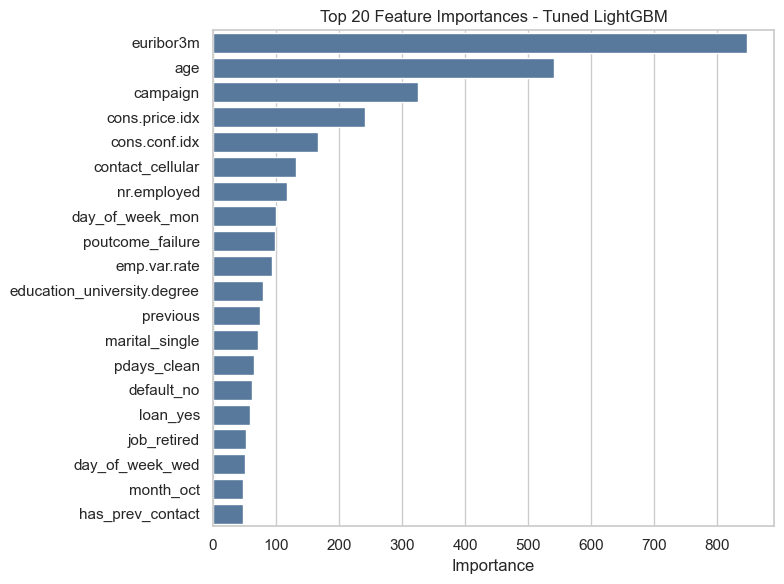

In [14]:
importance = pd.Series(best_lgb_model.feature_importances_, index=X_train.columns)
importance = importance.sort_values(ascending=False).head(20)

display(importance.rename("importance").to_frame())

plt.figure(figsize=(8, 6))
sns.barplot(x=importance.values, y=importance.index, color="#4C78A8")
plt.title("Top 20 Feature Importances - Tuned LightGBM")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "feature_importance_top20.png", dpi=150)
plt.show()


## 15. 阈值曲线

模型输出的是“认购概率”。我们需要选择一个阈值，把概率变成 `yes/no`。

阈值越低：能找出更多潜在客户，但误报也更多。  
阈值越高：联系名单更精准，但会漏掉更多客户。


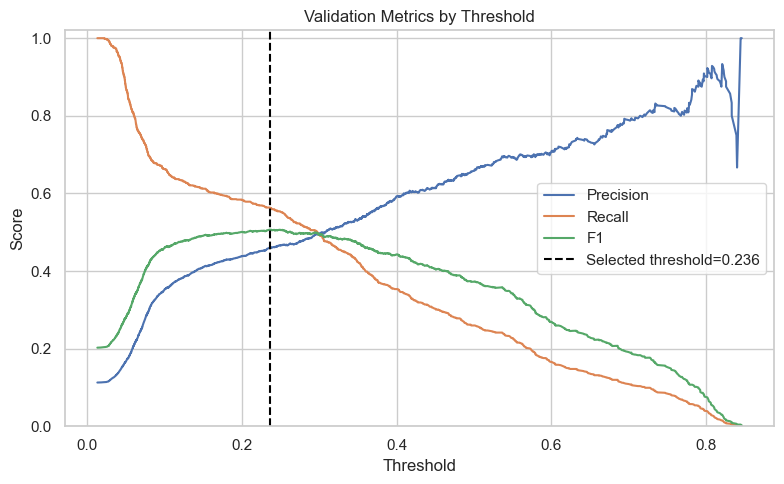

In [15]:
val_prob = best_lgb_model.predict_proba(X_val)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, val_prob)
f1_scores = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
best_threshold = tuned_result["threshold_from_val"]

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.plot(thresholds, f1_scores, label="F1")
plt.axvline(best_threshold, color="black", linestyle="--", label=f"Selected threshold={best_threshold:.3f}")
plt.title("Validation Metrics by Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.ylim(0, 1.02)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "threshold_curve.png", dpi=150)
plt.show()


## 16. 结论

这版 notebook 的推荐模型是：**不使用 `duration`、保留宏观经济变量、经过小范围调优的 LightGBM**。

这不是“完美模型”，但它比旧版更适合真实业务预测，也更适合新手学习完整流程。


In [16]:
final_summary = {
    "recommended_model": "LightGBM Tuned",
    "do_not_use": "duration",
    "best_params": best_params,
    "selected_threshold": tuned_result["threshold_from_val"],
    "test_pr_auc": tuned_result["test_pr_auc"],
    "test_roc_auc": tuned_result["test_roc_auc"],
    "test_precision_yes": tuned_result["test_precision_yes"],
    "test_recall_yes": tuned_result["test_recall_yes"],
    "test_f1_yes": tuned_result["test_f1_yes"],
    "confusion_matrix": tuned_result["confusion_matrix"].tolist(),
}

for key, value in final_summary.items():
    print(f"{key}: {value}")


recommended_model: LightGBM Tuned
do_not_use: duration
best_params: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': -1, 'min_child_samples': 120, 'n_estimators': 300, 'num_leaves': 31, 'reg_alpha': 0.1, 'reg_lambda': 0, 'subsample': 0.8}
selected_threshold: 0.2361525947611436
test_pr_auc: 0.49229956894297117
test_roc_auc: 0.8185442119911317
test_precision_yes: 0.4851138353765324
test_recall_yes: 0.5969827586206896
test_f1_yes: 0.5352657004830917
confusion_matrix: [[6722, 588], [374, 554]]


## 17. 时间切分验证：用过去预测未来

前面的训练/验证/测试是随机切分，适合学习模型流程。真实营销更接近这个问题：

> 用过去的客户和营销记录训练模型，预测未来一段时间哪些客户更可能认购。

这个数据集原始文件已经按时间排序，但没有精确日期列。因此这里用行顺序近似时间顺序：

- 前 60%：训练集
- 中间 20%：验证集，用来选择阈值
- 最后 20%：测试集，模拟未来数据

这个检查比随机切分更严格，也更接近业务上线后的情况。


,split,rows,yes_rate
0,train_first_60%,24712,0.0481
1,validation_next_20%,8238,0.1107
2,test_last_20%,8238,0.3083


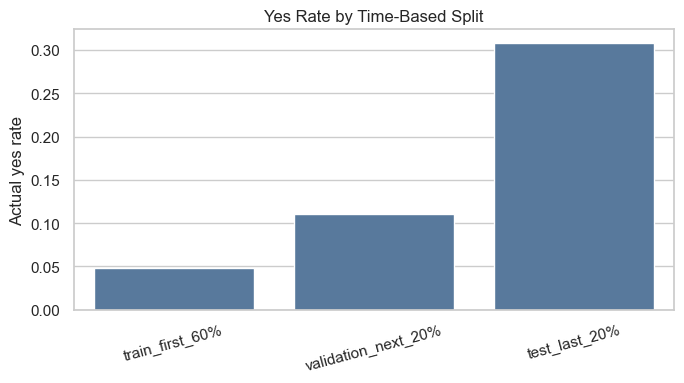

In [17]:
X_time, y_time = build_model_data(df, include_macro=True, include_duration=False)

n_rows = len(X_time)
train_end = int(n_rows * 0.60)
val_end = int(n_rows * 0.80)

X_time_train = X_time.iloc[:train_end]
y_time_train = y_time.iloc[:train_end]
X_time_val = X_time.iloc[train_end:val_end]
y_time_val = y_time.iloc[train_end:val_end]
X_time_test = X_time.iloc[val_end:]
y_time_test = y_time.iloc[val_end:]

time_split_rates = pd.DataFrame({
    "split": ["train_first_60%", "validation_next_20%", "test_last_20%"],
    "rows": [len(y_time_train), len(y_time_val), len(y_time_test)],
    "yes_rate": [y_time_train.mean(), y_time_val.mean(), y_time_test.mean()],
})
display(time_split_rates.round(4))

plt.figure(figsize=(7, 4))
sns.barplot(data=time_split_rates, x="split", y="yes_rate", color="#4C78A8")
plt.title("Yes Rate by Time-Based Split")
plt.xlabel("")
plt.ylabel("Actual yes rate")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "time_split_yes_rate.png", dpi=150)
plt.show()


In [18]:
time_model = lgb.LGBMClassifier(
    objective="binary",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
    **best_params,
)

time_model.fit(
    X_time_train,
    y_time_train,
    eval_set=[(X_time_val, y_time_val)],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(80, verbose=False)],
)

time_val_prob = time_model.predict_proba(X_time_val)[:, 1]
time_threshold_info = find_best_f1_threshold(y_time_val, time_val_prob)
time_threshold = time_threshold_info["threshold"]

time_test_prob = time_model.predict_proba(X_time_test)[:, 1]
time_test_pred = (time_test_prob >= time_threshold).astype(int)

time_result = {
    "model": "LightGBM Tuned - Time Split",
    "threshold_from_time_val": time_threshold,
    "test_pr_auc": average_precision_score(y_time_test, time_test_prob),
    "test_roc_auc": roc_auc_score(y_time_test, time_test_prob),
    "test_precision_yes": precision_score(y_time_test, time_test_pred, zero_division=0),
    "test_recall_yes": recall_score(y_time_test, time_test_pred, zero_division=0),
    "test_f1_yes": f1_score(y_time_test, time_test_pred, zero_division=0),
    "test_pred_yes_rate": time_test_pred.mean(),
    "confusion_matrix": confusion_matrix(y_time_test, time_test_pred),
}

display(pd.DataFrame([{k: v for k, v in time_result.items() if k != "confusion_matrix"}]).round(4))

print("时间切分测试集分类报告:")
print(classification_report(y_time_test, time_test_pred, target_names=["no", "yes"]))
print("混淆矩阵 [[TN, FP], [FN, TP]]:")
print(time_result["confusion_matrix"])


,model,threshold_from_time_val,test_pr_auc,test_roc_auc,test_precision_yes,test_recall_yes,test_f1_yes,test_pred_yes_rate
0,LightGBM Tuned - Time Split,0.0516,0.2898,0.4352,0.2651,0.5425,0.3562,0.631


时间切分测试集分类报告:
              precision    recall  f1-score   support

          no       0.62      0.33      0.43      5698
         yes       0.27      0.54      0.36      2540

    accuracy                           0.40      8238
   macro avg       0.44      0.44      0.39      8238
weighted avg       0.51      0.40      0.41      8238

混淆矩阵 [[TN, FP], [FN, TP]]:
[[1878 3820]
 [1162 1378]]


## 18. Top 客户分层收益分析

在营销业务里，模型最常见的用法不是直接输出 `yes/no`，而是给客户排序：

- Top 10%：最优先联系
- Top 20%：营销资源稍多时联系
- Top 30%：更宽松的联系名单

我们用时间切分测试集模拟“未来客户名单”，看模型排在前面的客户是否真的有更高认购率。


,feature_set,test_pr_auc,test_roc_auc
0,with_macro,0.4756,0.6583
1,no_macro,0.5233,0.6907


推荐客户排序模型: No Macro Future Ranking Model
时间测试集整体 yes 率: 30.83%
时间测试集实际 yes 客户数: 2540


,contact_group,contact_customers,actual_yes,response_rate,lift_vs_baseline,captured_yes_rate
0,Top 10%,824,541,0.6566,2.1294,0.2130
1,Top 20%,1648,987,0.5989,1.9424,0.3886
2,Top 30%,2472,1280,0.5178,1.6794,0.5039


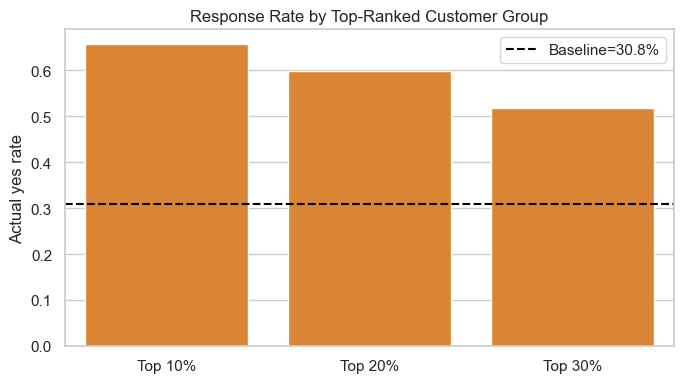

In [19]:
def top_percent_lift_table(y_true, predicted_prob, percents=(0.10, 0.20, 0.30)):
    scored = pd.DataFrame({
        "actual": np.asarray(y_true),
        "predicted_prob": np.asarray(predicted_prob),
    }).sort_values("predicted_prob", ascending=False).reset_index(drop=True)

    total_customers = len(scored)
    total_yes = int(scored["actual"].sum())
    baseline_rate = scored["actual"].mean()

    rows = []
    for pct in percents:
        contact_n = int(np.ceil(total_customers * pct))
        selected = scored.head(contact_n)
        selected_yes = int(selected["actual"].sum())
        selected_rate = selected["actual"].mean()
        rows.append({
            "contact_group": f"Top {int(pct * 100)}%",
            "contact_customers": contact_n,
            "actual_yes": selected_yes,
            "response_rate": selected_rate,
            "lift_vs_baseline": selected_rate / baseline_rate if baseline_rate > 0 else np.nan,
            "captured_yes_rate": selected_yes / total_yes if total_yes > 0 else np.nan,
        })

    return pd.DataFrame(rows), baseline_rate, total_yes


def train_future_ranking_model(include_macro=True):
    X_rank, y_rank = build_model_data(df, include_macro=include_macro, include_duration=False)
    rank_train_end = int(len(X_rank) * 0.80)

    X_rank_train = X_rank.iloc[:rank_train_end]
    y_rank_train = y_rank.iloc[:rank_train_end]
    X_rank_test = X_rank.iloc[rank_train_end:]
    y_rank_test = y_rank.iloc[rank_train_end:]

    rank_model = lgb.LGBMClassifier(
        objective="binary",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
        **best_params,
    )
    rank_model.fit(X_rank_train, y_rank_train)
    rank_prob = rank_model.predict_proba(X_rank_test)[:, 1]

    rank_metrics = {
        "feature_set": "with_macro" if include_macro else "no_macro",
        "test_pr_auc": average_precision_score(y_rank_test, rank_prob),
        "test_roc_auc": roc_auc_score(y_rank_test, rank_prob),
    }
    rank_lift_table, rank_baseline_rate, rank_total_yes = top_percent_lift_table(y_rank_test, rank_prob)
    return rank_metrics, rank_lift_table, rank_baseline_rate, rank_total_yes, rank_prob, y_rank_test


rank_with_macro = train_future_ranking_model(include_macro=True)
rank_no_macro = train_future_ranking_model(include_macro=False)

future_rank_compare = pd.DataFrame([rank_with_macro[0], rank_no_macro[0]])
display(future_rank_compare.round(4))

if rank_no_macro[0]["test_pr_auc"] >= rank_with_macro[0]["test_pr_auc"]:
    selected_rank_name = "No Macro Future Ranking Model"
    selected_rank_metrics, lift_table, time_baseline_rate, time_total_yes, future_rank_prob, future_rank_y = rank_no_macro
else:
    selected_rank_name = "With Macro Future Ranking Model"
    selected_rank_metrics, lift_table, time_baseline_rate, time_total_yes, future_rank_prob, future_rank_y = rank_with_macro

print(f"推荐客户排序模型: {selected_rank_name}")
print(f"时间测试集整体 yes 率: {time_baseline_rate:.2%}")
print(f"时间测试集实际 yes 客户数: {time_total_yes}")
display(lift_table.round(4))

plt.figure(figsize=(7, 4))
sns.barplot(data=lift_table, x="contact_group", y="response_rate", color="#F58518")
plt.axhline(time_baseline_rate, color="black", linestyle="--", label=f"Baseline={time_baseline_rate:.1%}")
plt.title("Response Rate by Top-Ranked Customer Group")
plt.xlabel("")
plt.ylabel("Actual yes rate")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "top_customer_lift_time_holdout.png", dpi=150)
plt.show()


## 19. 追加优化结论

随机切分告诉我们模型在“同分布抽样”下的表现；时间切分告诉我们模型面对未来数据时是否稳定。  
Top 客户分层则把模型结果翻译成营销名单策略，比单独看 AUC 更接近业务决策。


In [20]:
optimization_log_path = PROJECT_DIR / "bank-marketing-optimization-log.md"

time_metrics = {k: v for k, v in time_result.items() if k != "confusion_matrix"}
lift_table_text = lift_table.round(4).to_string(index=False)

log_text = (
    "# Bank Marketing 优化日志\n\n"
    "## 记录日期\n\n"
    "2026-06-04\n\n"
    "## 本次新增优化\n\n"
    "1. 新增时间切分验证：使用前 60% 样本训练，中间 20% 样本选择阈值，最后 20% 样本模拟未来测试。\n"
    "2. 新增未来客户排序模型：使用前 80% 历史样本训练，最后 20% 样本模拟未来客户名单排序。\n"
    "3. 新增 Top 客户分层收益分析：评估 Top 10%、Top 20%、Top 30% 客户名单的实际认购率、提升倍数和覆盖的 yes 客户比例。\n"
    "4. 新增图表输出：\n"
    "   - `figures_beginner/time_split_yes_rate.png`\n"
    "   - `figures_beginner/top_customer_lift_time_holdout.png`\n\n"
    "## 随机切分模型结果\n\n"
    "- 推荐模型：LightGBM Tuned\n"
    f"- 测试集 PR-AUC：{tuned_result['test_pr_auc']:.4f}\n"
    f"- 测试集 ROC-AUC：{tuned_result['test_roc_auc']:.4f}\n"
    f"- yes precision：{tuned_result['test_precision_yes']:.4f}\n"
    f"- yes recall：{tuned_result['test_recall_yes']:.4f}\n"
    f"- yes F1：{tuned_result['test_f1_yes']:.4f}\n"
    f"- 混淆矩阵：{tuned_result['confusion_matrix'].tolist()}\n\n"
    "## 时间切分阈值验证结果\n\n"
    f"- 时间测试集 PR-AUC：{time_metrics['test_pr_auc']:.4f}\n"
    f"- 时间测试集 ROC-AUC：{time_metrics['test_roc_auc']:.4f}\n"
    f"- yes precision：{time_metrics['test_precision_yes']:.4f}\n"
    f"- yes recall：{time_metrics['test_recall_yes']:.4f}\n"
    f"- yes F1：{time_metrics['test_f1_yes']:.4f}\n"
    f"- 混淆矩阵：{time_result['confusion_matrix'].tolist()}\n\n"
    "## 未来客户排序模型结果\n\n"
    f"- 推荐排序模型：{selected_rank_name}\n"
    f"- 排序测试集 PR-AUC：{selected_rank_metrics['test_pr_auc']:.4f}\n"
    f"- 排序测试集 ROC-AUC：{selected_rank_metrics['test_roc_auc']:.4f}\n\n"
    "## Top 客户分层结果\n\n"
    f"时间测试集整体 yes 率：{time_baseline_rate:.2%}\n\n"
    f"{lift_table_text}\n\n"
    "## 解读\n\n"
    "- 时间切分阈值验证显示：模型从随机切分迁移到未来数据时明显变难，存在时间分布漂移。\n"
    "- 对营销名单来说，排序比直接分类更实用；使用前 80% 历史数据训练后的 Top 客户分层有明显提升。\n"
    "- 当前结果中 Top 10% 客户的实际认购率约为整体未来样本的 2 倍以上，适合优先联系。\n"
    "- 后续可以继续做按月份/宏观周期的时间漂移分析，或按营销资源容量选择 Top N 客户名单。\n"
)

optimization_log_path.write_text(log_text, encoding="utf-8")
print(f"优化日志已保存: {optimization_log_path}")


优化日志已保存: C:\Users\王莹\Documents\My_AI_projects\bank_marketing\bank-marketing-optimization-log.md
